**Diana Itzel Soto Castañeda**

**Ciencia de Datos para Sensores Inteligentes**

## Imports

In [38]:
# system libraries
import os
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
Executable: c:\Users\Diana\git\Course_CDSI_2026\practicas\PR1_Reconocimiento_Audio\.venv\Scripts\python.exe


Nota: Los entornos virtuales (.venv) no se encuentran en el repositorio de GitHub.

In [39]:
# data 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# audio
import IPython.display as ipd
from IPython.display import Audio, display, Markdown
import librosa
import librosa.display

# warnings
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [40]:
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# Practica 1 — Reconocimiento de ADLs con audio


## Introducción

En esta práctica se aborda el reconocimiento de *Activities of Daily Living (ADLs)* utilizando señales de audio como fuente principal de información, el objetivo es el de identificar las siguientes actividades:
- Bajarle al WC (Bano)
- Lavar platos (Cocina)
- Conversación (Sala)
- Música de fondo (Oficina)
- Pasos al caminar (Múltiples lugares) [Pasos]
- Otros sonidos (Nula)

El desarrollo de la práctica sigue el siguiente flujo: Recolección y organización de datos, preprocesamiento de las señales de audio, extracción y selección de características relevantes, y finalmente la construcción y evaluación de modelos de clasificación

## Objetivo

El objetivo principal de esta práctica es aplicar técnicas de análisis de datos y aprendizaje automático para entrenar modelos capaces de reconocer automáticamente distintas actividades a partir de audio, así como evaluar su desempeño mediante métricas típicas.

## Desarrollo

Definición de etiquetas

In [41]:
## Definición de etiquetas válidas
Etiquetas_validas = {
    "BANO", "COCINA", "NULA",
    "OFICINA", "PASOS", "SALA"
}

### Recolección de audios y conformación del dataset

Los datos recolectados se encuentran en la carpeta Data de esta carpeta de proyecto. Los audios tiene una duración de 10 segundos y se recolectaron de manera colectiva.

### Procesamiento de los audios

In [42]:
#!pip install librosa

Carga de datos

In [43]:
Data = "data"
os.listdir(Data)

['Diana Itzel',
 'Diana Jaramillo',
 'Eric R',
 'Ian Svén',
 'Javier R',
 'José Juárez',
 'Mariel Lopez',
 'Norman O',
 'Test Joan Raygoza',
 'Zarif León']

In [44]:
dirl_list = os.listdir(Data)
print(dirl_list)

for estudiante in dirl_list:
    path_estudiante = os.path.join(Data, estudiante)
    print(f"\n📁 {estudiante}")
    print(os.listdir(path_estudiante))

['Diana Itzel', 'Diana Jaramillo', 'Eric R', 'Ian Svén', 'Javier R', 'José Juárez', 'Mariel Lopez', 'Norman O', 'Test Joan Raygoza', 'Zarif León']

📁 Diana Itzel
['DISC_BANO_01.wav', 'DISC_BANO_02.wav', 'DISC_BANO_03.wav', 'DISC_COCINA_01.wav', 'DISC_COCINA_02.wav', 'DISC_COCINA_03.wav', 'DISC_NULA_01.wav', 'DISC_NULA_02.wav', 'DISC_NULA_03.wav', 'DISC_OFICINA_01.wav', 'DISC_OFICINA_02.wav', 'DISC_OFICINA_03.wav', 'DISC_PASOS_01.wav', 'DISC_PASOS_02.wav', 'DISC_PASOS_03.wav', 'DISC_SALA_01.wav', 'DISC_SALA_02.wav', 'DISC_SALA_03.wav']

📁 Diana Jaramillo
['DMJD_bano_01.wav', 'DMJD_bano_02.wav', 'DMJD_bano_03.wav', 'DMJD_cocina_01.wav', 'DMJD_cocina_02.wav', 'DMJD_cocina_03.wav', 'DMJD_nula_01.wav', 'DMJD_nula_02.wav', 'DMJD_nula_03.wav', 'DMJD_oficina_01.wav', 'DMJD_oficina_02.wav', 'DMJD_oficina_03.wav', 'DMJD_pasos_01.wav', 'DMJD_pasos_02.wav', 'DMJD_pasos_03.wav', 'DMJD_sala_01.wav', 'DMJD_sala_02.wav', 'DMJD_sala_03.wav']

📁 Eric R
['EARA_BANO_01.wav', 'EARA_BANO_02.wav', 'EARA_BANO

Dado que al iniciar la práctica se identificaron etiquetas discrepantes en los nombres de los archivos de audio, así como carpetas vacías correspondientes a algunos compañeros de clase, se decidió implementar mecanismos de validación y normalización durante la carga de los datos. Además se separan los datos de prueba de los datos de entrenamiento:

In [45]:
TEST_FOLDER = "Test Joan Raygoza"
data_train = []
data_test = []

In [46]:
# Construcción del DataFrame
for estudiante in dirl_list:
    path_estudiante = os.path.join(Data, estudiante)

    if not os.path.isdir(path_estudiante):
        continue

    archivos = os.listdir(path_estudiante)
    if len(archivos) == 0:
        print(f"Carpeta vacía: {estudiante}")
        continue

    for archivo in archivos:
        if not archivo.lower().endswith(".wav"):
            continue

        # Extraer etiqueta
        nombre = archivo.replace(".wav", "")
        partes = nombre.split("_")

        if len(partes) < 2:
            print(f"Archivo ignorado (formato inválido): {archivo}")
            continue

        label = partes[1].upper()

        # Unificar NULO y NULA
        if label == "NULO":
            label = "NULA"

        if label not in Etiquetas_validas:
            print(f"Archivo ignorado (etiqueta inválida): {archivo}")
            continue

        path_archivo = os.path.join(path_estudiante, archivo)
        senal, sr = librosa.load(path_archivo, sr=None)

        registro = {
            "estudiante": estudiante,
            "archivo": archivo,
            "etiqueta": label,
            "senal": senal,
            "sr": sr
        }

        # Separación del conjunto de prueba y el conjunto de entrenamiento
        if estudiante == TEST_FOLDER:
            data_test.append(registro)
        else:
            data_train.append(registro)


CDSI2026_train_df = pd.DataFrame(data_train)
CDSI2026_test_df = pd.DataFrame(data_test)


Exploración de datos

Previo al preprocesamiento, se realizó una inspección exploratoria básica una señal de audio aleatoria mediante la reproducción y visualización de formas de onda y espectrogramas.

In [47]:
# Escucha de una muestra aleatoria
row_train = CDSI2026_train_df.sample(1, random_state=92).iloc[0]
print("Actividad:", row_train["etiqueta"]) 
display(Audio(row_train["senal"], rate=row_train["sr"]))

Actividad: NULA


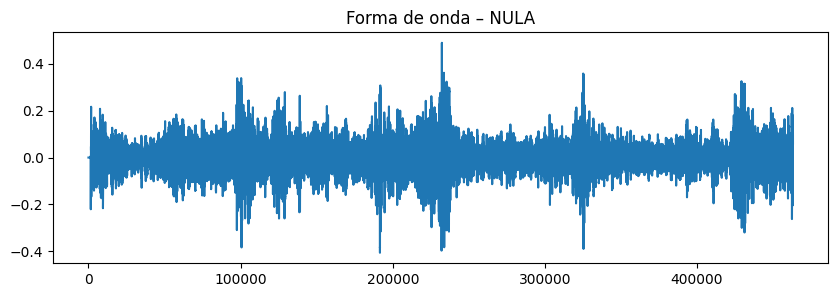

In [48]:
# Visualización de la forma de onda
plt.figure(figsize=(10,3))
plt.plot(row_train["senal"])
plt.title(f"Forma de onda – {row_train['etiqueta']}")
plt.show()


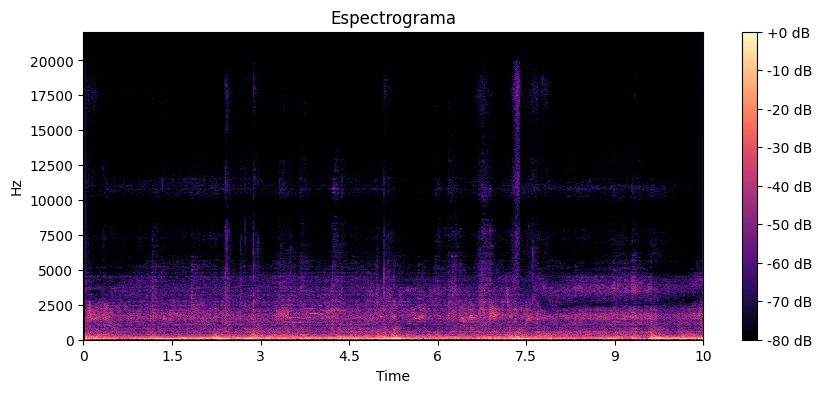

In [49]:
# Espectrograma
S = librosa.stft(row_train["senal"])
S_db = librosa.amplitude_to_db(abs(S), ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(S_db, sr=row_train["sr"], x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma")
plt.show()


#### Aplicar una función para eliminar ruidos estacionarios de fondo

Aplicar la función eliminar_ruido_estacionario y generar una nueva columna con datos de la señal sin ruido

In [50]:
def aplicar_eliminacion_ruido(senal, sr, percentil_ruido=10):
    """Elimina ruido estacionario de una señal de audio"""
    S = librosa.stft(senal)
    magnitud, fase = librosa.magphase(S)
    perfil_ruido = np.percentile(magnitud, percentil_ruido, axis=1, keepdims=True)
    magnitud_limpia = np.maximum(magnitud - perfil_ruido, 0)
    S_limpia = magnitud_limpia * fase
    senal_sinruido = librosa.istft(S_limpia)
    return senal_sinruido

# Aplicar función al conjunto de entrenamiento
CDSI2026_train_df["senal_sin_ruido"] = CDSI2026_train_df.apply(
    lambda row_train: aplicar_eliminacion_ruido(row_train["senal"], row_train["sr"]),
    axis=1
)

# Aplicar función al conjunto de prueba
CDSI2026_test_df["senal_sin_ruido"] = CDSI2026_test_df.apply(
    lambda row_test: aplicar_eliminacion_ruido(row_test["senal"], row_test["sr"]),
    axis=1
)

Comparar Espectrogramas con y sin ruido de fondo

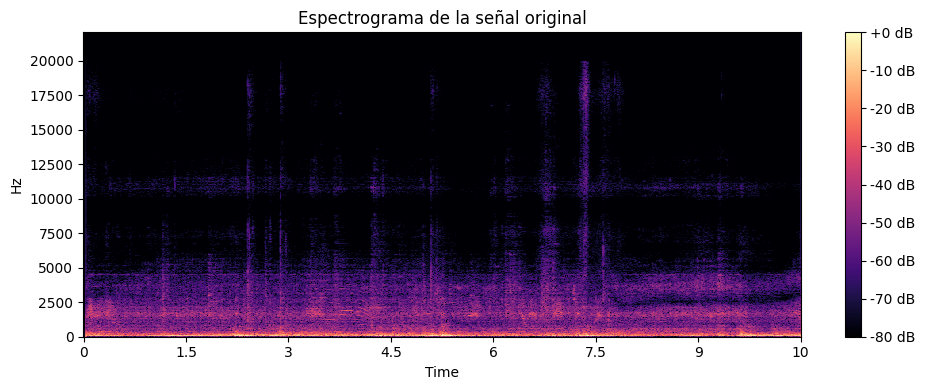

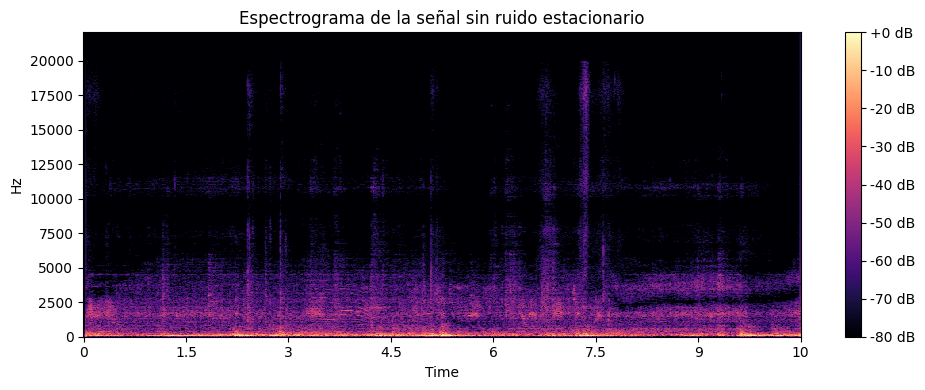

In [51]:
row_train = CDSI2026_train_df.sample(1, random_state=92).iloc[0]
# STFT - Señal original
S = librosa.stft(row_train["senal"])

# Convertir a decibeles
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

# Graficar espectrograma
plt.figure(figsize=(10,4))
librosa.display.specshow(
    S_db,
    sr=row_train["sr"],
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma de la señal original")
plt.tight_layout()
plt.show()

# STFT - Señal sin ruido
S = librosa.stft(row_train["senal_sin_ruido"])
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    S_db,
    sr=row_train["sr"],
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma de la señal sin ruido estacionario")
plt.tight_layout()
plt.show()

In [52]:
print("Original")
display(Audio(row_train["senal"], rate=row_train["sr"]))

print("Sin ruido estacionario")
display(Audio(row_train["senal_sin_ruido"], rate=row_train["sr"]))

Original


Sin ruido estacionario


Aunque la diferencia perceptual entre la señal original y la señal procesada es sutil, el análisis en el dominio de la frecuencia mediante espectrogramas permitió identificar, en algunos casos específicos, una reducción de componentes asociadas al ruido estacionario de fondo. 

#### Aplicar una función de normalización para asegurar un volumen constante y evitar sesgos

In [53]:
# Conjunto de entrenamiento
CDSI2026_train_df["senal_normalizada"] = CDSI2026_train_df["senal_sin_ruido"].apply(
    lambda s: librosa.util.normalize(s)
)

# Conjunto de prueba
CDSI2026_test_df["senal_normalizada"] = CDSI2026_test_df["senal_sin_ruido"].apply(
    lambda s: librosa.util.normalize(s)
)


# Verificación de la normalización
row_train = CDSI2026_train_df.sample(1).iloc[0]
print("Máx normalizada:", np.max(np.abs(row_train["senal_normalizada"])))

Máx normalizada: 1.0


### Extracción y selección de características

#### MFCC

In [54]:
#Entrenamiento
mfccs_train = []

for _, row_train in CDSI2026_train_df.iterrows():
    mfcc_train = librosa.feature.mfcc(
        y=row_train["senal_normalizada"],
        sr=row_train["sr"],
        n_mfcc=13
    )
    mfccs_train.append(np.mean(mfcc_train, axis=1))

mfcc_train_df = pd.DataFrame(
    mfccs_train,
    columns=[f"mfcc_{i+1}" for i in range(13)]
)

#Prueba
mfccs_test = []
for _, row_test in CDSI2026_test_df.iterrows():
    mfcc_test = librosa.feature.mfcc(y=row_test["senal_normalizada"], sr=row_test["sr"], n_mfcc=13)
    mfccs_test.append(np.mean(mfcc_test, axis=1))
mfcc_test_df = pd.DataFrame(mfccs_test, columns=[f"mfcc_{i+1}" for i in range(13)])

#### Zero Crossing Rate

In [55]:
#Entrenamiento
#Entrenamiento
zcr_train = []
for _, row_train in CDSI2026_train_df.iterrows():
    z = librosa.feature.zero_crossing_rate(row_train["senal_normalizada"])
    # append to the TRAIN list (fixed variable name)
    zcr_train.append(np.mean(z))

# Construir DataFrame de entrenamiento (usar la lista correcta)
zcr_train_df = pd.DataFrame(zcr_train, columns=["zcr"])

# Prueba
zcr_test = []
for _, row_test in CDSI2026_test_df.iterrows():
    z = librosa.feature.zero_crossing_rate(row_test["senal_normalizada"]) 
    zcr_test.append(np.mean(z))
zcr_test_df = pd.DataFrame(zcr_test, columns=["zcr"])

#### Energía (RMS)

In [56]:
#Entrenamiento
rms_train = []

for _, row_train in CDSI2026_train_df.iterrows():
    r = librosa.feature.rms(y=row_train["senal_normalizada"])
    rms_train.append(np.mean(r))

rms_train_df = pd.DataFrame(rms_train, columns=["rms"])

#Prueba
rms_test = []
for _, row_test in CDSI2026_test_df.iterrows():
    r = librosa.feature.rms(y=row_test["senal_normalizada"]) 
    rms_test.append(np.mean(r))
rms_test_df = pd.DataFrame(rms_test, columns=["rms"]) 

Ahora se vincula cada vector de las características extraidas con su respectiva etiqueta de actividad y se verifica la concatenación

In [57]:
# Con datos de entrenamiento: construir la matriz completa de características (no sobrescribir X_train)
X = pd.concat([mfcc_train_df, zcr_train_df, rms_train_df], axis=1)
y = CDSI2026_train_df["etiqueta"]

# Mostrar una vista rápida para verificar
display(X.head())  # primeras filas de la matriz de características
display(y.head())  # primeras etiquetas

# Ensamblar X_test_external y y_test_external (conjunto externo separado)
X_test_external = pd.concat([mfcc_test_df, zcr_test_df, rms_test_df], axis=1)
y_test_external = CDSI2026_test_df["etiqueta"]

print("Full feature matrix shape:", X.shape)
print("External test shape:", X_test_external.shape)
print(y_test_external.value_counts())

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,zcr,rms
0,-227.945526,109.254883,-39.314205,-0.735043,-11.228836,27.293726,-6.795474,11.656944,7.840952,16.683451,-1.111534,4.151556,-5.844520,0.083297,0.060077
1,-210.259918,64.928917,-13.124597,32.933235,-0.399469,18.912355,-16.998960,10.134212,-14.861896,7.247721,-7.308037,4.009565,-3.795467,0.133384,0.070453
2,-262.514893,81.101189,-5.396962,25.025723,-5.228497,15.438561,-20.155287,9.749455,-6.270298,7.629604,-5.338158,1.288002,-7.674201,0.114772,0.044989
3,-269.289581,95.876587,-17.918037,31.598492,-7.222451,17.862984,-10.631896,20.848959,-8.691792,9.706056,-3.223147,11.347348,-8.622421,0.131182,0.036618
4,-349.234222,102.035255,-8.504502,16.836105,-6.263916,5.834454,-6.194636,4.633437,-4.256493,-1.288900,-3.306655,3.997533,-0.508150,0.083178,0.032184


0      BANO
1      BANO
2      BANO
3    COCINA
4    COCINA
Name: etiqueta, dtype: object

Full feature matrix shape: (165, 15)
External test shape: (18, 15)
etiqueta
BANO       3
COCINA     3
NULA       3
OFICINA    3
PASOS      3
SALA       3
Name: count, dtype: int64


### Construcción y evaluación de modelos

Como parte de la práctica se construirán y evaluarán tres modelos de clasificación.

#### Separación de datos para **evaluación justa**

In [58]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3, #30% para test, 70% para train
    random_state=93, 
)

y_test.value_counts()

etiqueta
SALA       13
BANO       12
OFICINA     8
NULA        7
COCINA      5
PASOS       5
Name: count, dtype: int64

Al ver la distribución de los datos sin estratificación, decidí implementar una estratificación en búsqueda de mejorar la distribución:

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3, #30% para test, 70% para train
    random_state=93,
    stratify=y # Mantener la proporción de clases en ambos conjuntos dado que el dataset es pequeño 
)

y_test.value_counts()

etiqueta
PASOS      9
NULA       9
BANO       8
COCINA     8
SALA       8
OFICINA    8
Name: count, dtype: int64

#### Escalado de características.

Si las características tienen escalas distintas pueden confundir al modelo, el escalado le da el mismo peso a todas las características.

In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Escalar external usando el scaler ajustado en X_train
X_test_external_scaled = scaler.transform(X_test_external)


In [61]:
# Se agregó este bloque para intentar comprender porque los modelos no ajustan adecuadamente una vez completado el pipel
print('--- Shape & counts ---')
print('X shape:', X.shape)
print('X_test_external shape:', X_test_external.shape)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape:', X_test_scaled.shape)
print('X_test_external_scaled shape:', X_test_external_scaled.shape)
print()
print('y distributions:')
print('train:\n', y_train.value_counts())
print('test:\n', y_test.value_counts())
print('external test:\n', y_test_external.value_counts())
print()
# Baseline: majority class from train on external test
maj = y_train.mode()[0]
maj_acc = (y_test_external == maj).mean()
print('Majority-class (train) on external test acc:', round(maj_acc,3))

# Overfit check (SVM) and feature importances
try:
    print('\nTrain accuracy SVM RBF:', (svm_rbf.predict(X_train_scaled)==y_train).mean())
    print('Test accuracy SVM RBF:', (svm_rbf.predict(X_test_scaled)==y_test).mean())
except Exception as e:
    print('SVM not available yet or error:', e)

try:
    importances = rf_final.feature_importances_
    print('\nTop features RF:')
    names = list(X.columns)
    for n,i in sorted(zip(names, importances), key=lambda x: x[1], reverse=True)[:10]:
        print(n, round(i,4))
except Exception as e:
    print('RF not available yet or error:', e)

--- Shape & counts ---
X shape: (165, 15)
X_test_external shape: (18, 15)
X_train shape: (115, 15)
X_test shape: (50, 15)
X_train_scaled shape: (115, 15)
X_test_scaled shape: (50, 15)
X_test_external_scaled shape: (18, 15)

y distributions:
train:
 etiqueta
NULA       21
SALA       19
OFICINA    19
BANO       19
COCINA     19
PASOS      18
Name: count, dtype: int64
test:
 etiqueta
PASOS      9
NULA       9
BANO       8
COCINA     8
SALA       8
OFICINA    8
Name: count, dtype: int64
external test:
 etiqueta
BANO       3
COCINA     3
NULA       3
OFICINA    3
PASOS      3
SALA       3
Name: count, dtype: int64

Majority-class (train) on external test acc: 0.167

Train accuracy SVM RBF: 0.8869565217391304
Test accuracy SVM RBF: 0.66

Top features RF:
mfcc_2 0.1119
zcr 0.1004
mfcc_1 0.0824
mfcc_5 0.0777
rms 0.0761
mfcc_11 0.0657
mfcc_10 0.0649
mfcc_3 0.062
mfcc_8 0.0607
mfcc_6 0.0578


#### SVM (Support Vector Machine)

Se evaluó un modelo de *Support Vector Machine* empleando diferentes *kernels*, con el fin de analizar el impacto de la función de decisión en el desempeño del clasificador.

- Kernel RBF

In [62]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    random_state=92
)

svm_model.fit(X_train_scaled, y_train)
y_pred_rbf = svm_model.predict(X_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rbf))

              precision    recall  f1-score   support

        BANO       0.60      0.75      0.67         8
      COCINA       0.80      0.50      0.62         8
        NULA       0.50      0.56      0.53         9
     OFICINA       1.00      0.50      0.67         8
       PASOS       0.54      0.78      0.64         9
        SALA       0.88      0.88      0.88         8

    accuracy                           0.66        50
   macro avg       0.72      0.66      0.66        50
weighted avg       0.71      0.66      0.66        50



- Kernel lineal

In [63]:

svm_linear = SVC(kernel="linear", random_state=92)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_linear))


              precision    recall  f1-score   support

        BANO       0.57      1.00      0.73         8
      COCINA       0.80      0.50      0.62         8
        NULA       0.50      0.33      0.40         9
     OFICINA       0.33      0.38      0.35         8
       PASOS       0.40      0.44      0.42         9
        SALA       0.67      0.50      0.57         8

    accuracy                           0.52        50
   macro avg       0.55      0.53      0.51        50
weighted avg       0.54      0.52      0.51        50



- Kernel polinomial

In [64]:
svm_poly = SVC(kernel="poly", degree=3, random_state=42)
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_poly))


              precision    recall  f1-score   support

        BANO       0.50      0.75      0.60         8
      COCINA       0.60      0.38      0.46         8
        NULA       0.67      0.22      0.33         9
     OFICINA       1.00      0.12      0.22         8
       PASOS       0.35      0.89      0.50         9
        SALA       0.50      0.38      0.43         8

    accuracy                           0.46        50
   macro avg       0.60      0.46      0.42        50
weighted avg       0.60      0.46      0.42        50



A partir de la comparación entre los distintos kernels evaluados, se observó que el kernel RBF presenta el mejor desempeño global, mostrando un equilibrio más adecuado entre precisión y recall en la mayoría de las clases.

##### Evaluación del modelo

In [65]:
svm_rbf = SVC(kernel="rbf", C=1, gamma="scale", random_state=92)
svm_rbf.fit(X_train_scaled, y_train)
print("\nSVM RBF - internal")
print(classification_report(y_test, svm_rbf.predict(X_test_scaled)))
print("SVM RBF - external")
print(classification_report(y_test_external, svm_rbf.predict(X_test_external_scaled)))


SVM RBF - internal
              precision    recall  f1-score   support

        BANO       0.60      0.75      0.67         8
      COCINA       0.80      0.50      0.62         8
        NULA       0.50      0.56      0.53         9
     OFICINA       1.00      0.50      0.67         8
       PASOS       0.54      0.78      0.64         9
        SALA       0.88      0.88      0.88         8

    accuracy                           0.66        50
   macro avg       0.72      0.66      0.66        50
weighted avg       0.71      0.66      0.66        50

SVM RBF - external
              precision    recall  f1-score   support

        BANO       0.00      0.00      0.00         3
      COCINA       0.00      0.00      0.00         3
        NULA       0.09      0.33      0.14         3
     OFICINA       0.00      0.00      0.00         3
       PASOS       0.50      0.33      0.40         3
        SALA       0.00      0.00      0.00         3

    accuracy                          

### Ajuste de hiperparámetros para SVM (GridSearchCV)
Se inserta una búsqueda de hiperparámetros estratificada para el kernel RBF de SVM con el fin de reducir el sobreajuste.
Empleo StratifiedKFold sobre el conjunto de entrenamiento y puntuación macro-F1.

In [66]:
# GridSearchCV para SVM RBF
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
gs.fit(X_train_scaled, y_train)
print('Best params:', gs.best_params_)
print('Best CV f1_macro:', gs.best_score_)
best_svm = gs.best_estimator_
from sklearn.metrics import classification_report, accuracy_score
print('\nEval on internal test:')
y_pred_test = best_svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred_test))
print('Accuracy internal:', accuracy_score(y_test, y_pred_test))
print('\nEval on external test:')
y_pred_ext = best_svm.predict(X_test_external_scaled)
print(classification_report(y_test_external, y_pred_ext))
print('Accuracy external:', accuracy_score(y_test_external, y_pred_ext))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'C': 100, 'gamma': 0.01}
Best CV f1_macro: 0.6461640211640212

Eval on internal test:
              precision    recall  f1-score   support

        BANO       0.54      0.88      0.67         8
      COCINA       0.80      0.50      0.62         8
        NULA       0.43      0.33      0.38         9
     OFICINA       0.71      0.62      0.67         8
       PASOS       0.42      0.56      0.48         9
        SALA       0.83      0.62      0.71         8

    accuracy                           0.58        50
   macro avg       0.62      0.59      0.59        50
weighted avg       0.61      0.58      0.58        50

Accuracy internal: 0.58

Eval on external test:
              precision    recall  f1-score   support

        BANO       0.00      0.00      0.00         3
      COCINA       0.00      0.00      0.00         3
        NULA       0.12      0.33      0.18         3
     OFICINA       0.00      0

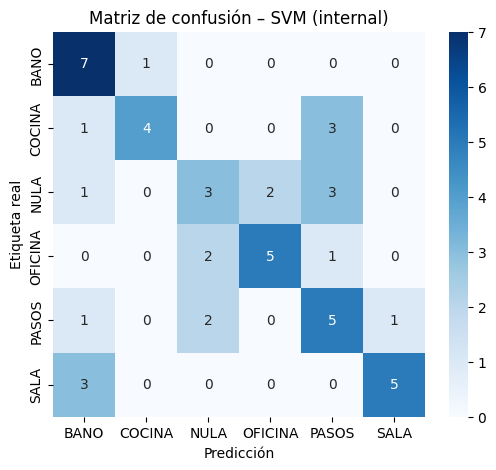

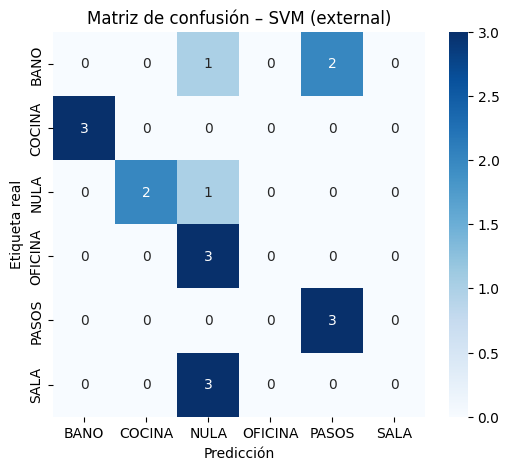

In [67]:
# Matrices de confusión para el SVM (mejor estimador) — internal y external
from sklearn.metrics import confusion_matrix
labels = y.unique()
# Internal
cm_int = confusion_matrix(y_test, y_pred_test, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_int, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión – SVM (internal)')
plt.show()
# External
cm_ext = confusion_matrix(y_test_external, y_pred_ext, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ext, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión – SVM (external)')
plt.show()

#### Radom Forest

A continuación evaluaremos el desempeño de Random Forest bajo distintas configuraciones para comparar su estabilidad y desempeño general.

Variando el número de árboles

In [68]:
from sklearn.ensemble import RandomForestClassifier

for n in [50, 100, 300]:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    # Entrenar usando características escaladas para mantener consistencia con SVM/KNN
    rf.fit(X_train_scaled, y_train)
    y_pred_rf = rf.predict(X_test_scaled)

    print(f"\nRandom Forest - n_estimators={n}")
    print(classification_report(y_test, y_pred_rf))



Random Forest - n_estimators=50
              precision    recall  f1-score   support

        BANO       0.56      0.62      0.59         8
      COCINA       0.44      0.50      0.47         8
        NULA       0.38      0.33      0.35         9
     OFICINA       0.50      0.62      0.56         8
       PASOS       0.67      0.44      0.53         9
        SALA       0.88      0.88      0.88         8

    accuracy                           0.56        50
   macro avg       0.57      0.57      0.56        50
weighted avg       0.57      0.56      0.56        50


Random Forest - n_estimators=100
              precision    recall  f1-score   support

        BANO       0.55      0.75      0.63         8
      COCINA       0.50      0.50      0.50         8
        NULA       0.33      0.22      0.27         9
     OFICINA       0.45      0.62      0.53         8
       PASOS       0.67      0.44      0.53         9
        SALA       0.88      0.88      0.88         8

    accura

Controlando profundidad

In [69]:
for depth in [None, 5, 10]:
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        random_state=42
    )
    # Mantener consistencia: entrenar/predicción sobre datos escalados
    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)

    print(f"\nRandom Forest - max_depth={depth}")
    print(classification_report(y_test, y_pred))



Random Forest - max_depth=None
              precision    recall  f1-score   support

        BANO       0.64      0.88      0.74         8
      COCINA       0.44      0.50      0.47         8
        NULA       0.50      0.22      0.31         9
     OFICINA       0.50      0.62      0.56         8
       PASOS       0.71      0.56      0.62         9
        SALA       0.78      0.88      0.82         8

    accuracy                           0.60        50
   macro avg       0.60      0.61      0.59        50
weighted avg       0.60      0.60      0.58        50


Random Forest - max_depth=5
              precision    recall  f1-score   support

        BANO       0.64      0.88      0.74         8
      COCINA       0.57      0.50      0.53         8
        NULA       0.33      0.22      0.27         9
     OFICINA       0.56      0.62      0.59         8
       PASOS       0.67      0.67      0.67         9
        SALA       0.88      0.88      0.88         8

    accuracy    

Finalmente se evalua el modelo final

In [70]:
rf_final = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
# Entrenar sobre X_train escalado para comparación coherente con otros modelos
rf_final.fit(X_train_scaled, y_train)
print("\nRandom Forest - internal")
print(classification_report(y_test, rf_final.predict(X_test_scaled)))
print("Random Forest - external")
print(classification_report(y_test_external, rf_final.predict(X_test_external_scaled)))


Random Forest - internal
              precision    recall  f1-score   support

        BANO       0.64      0.88      0.74         8
      COCINA       0.44      0.50      0.47         8
        NULA       0.50      0.22      0.31         9
     OFICINA       0.50      0.62      0.56         8
       PASOS       0.71      0.56      0.62         9
        SALA       0.78      0.88      0.82         8

    accuracy                           0.60        50
   macro avg       0.60      0.61      0.59        50
weighted avg       0.60      0.60      0.58        50

Random Forest - external
              precision    recall  f1-score   support

        BANO       0.00      0.00      0.00         3
      COCINA       0.00      0.00      0.00         3
        NULA       0.00      0.00      0.00         3
     OFICINA       0.00      0.00      0.00         3
       PASOS       0.25      1.00      0.40         3
        SALA       0.00      0.00      0.00         3

    accuracy              

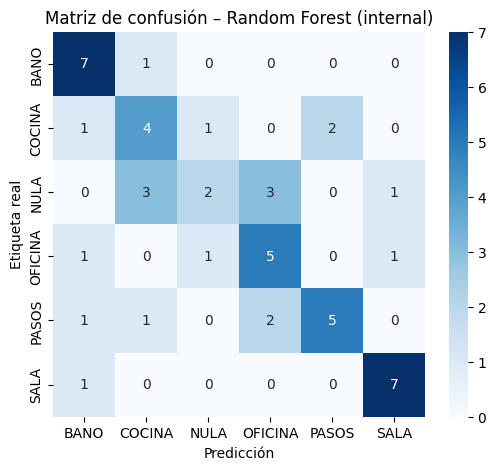

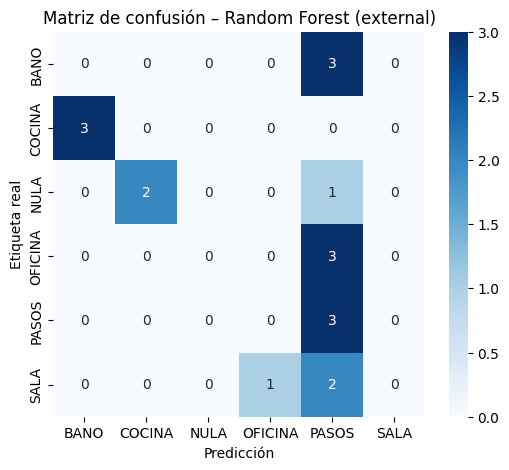

In [71]:
# Matrices de confusión para Random Forest (internal y external)
from sklearn.metrics import confusion_matrix
labels = y.unique()
y_pred_rf_int = rf_final.predict(X_test_scaled)
y_pred_rf_ext = rf_final.predict(X_test_external_scaled)
cm_rf_int = confusion_matrix(y_test, y_pred_rf_int, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf_int, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión – Random Forest (internal)')
plt.show()
cm_rf_ext = confusion_matrix(y_test_external, y_pred_rf_ext, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf_ext, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión – Random Forest (external)')
plt.show()

#### K-Nearest Neighbors (KNN)

Finalmente, se entrena y evalua el modelo empleando K-Nearest Neighboors

In [72]:
from sklearn.neighbors import KNeighborsClassifier

knn_base = KNeighborsClassifier(
    n_neighbors=5
)

knn_base.fit(X_train_scaled, y_train)
y_pred_knn = knn_base.predict(X_test_scaled)

print("KNN - baseline (k=5)")
print(classification_report(y_test, y_pred_knn))


KNN - baseline (k=5)
              precision    recall  f1-score   support

        BANO       0.54      0.88      0.67         8
      COCINA       0.50      0.38      0.43         8
        NULA       0.29      0.22      0.25         9
     OFICINA       0.67      0.50      0.57         8
       PASOS       0.44      0.44      0.44         9
        SALA       0.78      0.88      0.82         8

    accuracy                           0.54        50
   macro avg       0.54      0.55      0.53        50
weighted avg       0.53      0.54      0.52        50



##### Evaluación con conjunto de prueba

In [73]:


# KNN — usa X escalado
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_scaled, y_train)
print("\nKNN - internal")
print(classification_report(y_test, knn_final.predict(X_test_scaled)))
print("KNN - external")
print(classification_report(y_test_external, knn_final.predict(X_test_external_scaled)))



KNN - internal
              precision    recall  f1-score   support

        BANO       0.54      0.88      0.67         8
      COCINA       0.50      0.38      0.43         8
        NULA       0.29      0.22      0.25         9
     OFICINA       0.67      0.50      0.57         8
       PASOS       0.44      0.44      0.44         9
        SALA       0.78      0.88      0.82         8

    accuracy                           0.54        50
   macro avg       0.54      0.55      0.53        50
weighted avg       0.53      0.54      0.52        50

KNN - external
              precision    recall  f1-score   support

        BANO       0.00      0.00      0.00         3
      COCINA       0.00      0.00      0.00         3
        NULA       0.00      0.00      0.00         3
     OFICINA       0.00      0.00      0.00         3
       PASOS       0.33      1.00      0.50         3
        SALA       1.00      0.33      0.50         3

    accuracy                           0.22   

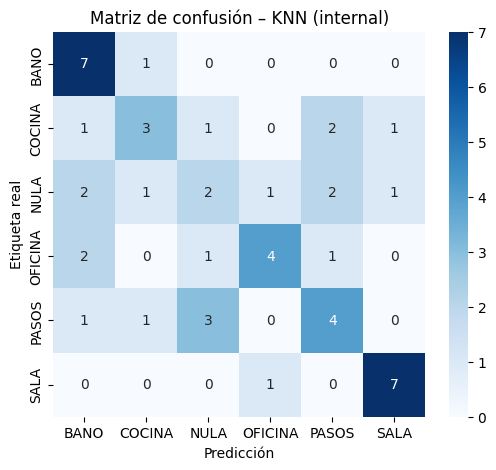

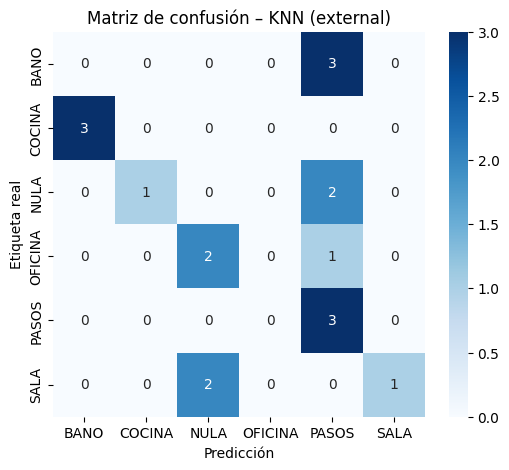

In [74]:
# Matrices de confusión para KNN (internal y external)
from sklearn.metrics import confusion_matrix
labels = y.unique()
y_pred_knn_int = knn_final.predict(X_test_scaled)
y_pred_knn_ext = knn_final.predict(X_test_external_scaled)
cm_knn_int = confusion_matrix(y_test, y_pred_knn_int, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_knn_int, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión – KNN (internal)')
plt.show()
cm_knn_ext = confusion_matrix(y_test_external, y_pred_knn_ext, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_knn_ext, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión – KNN (external)')
plt.show()

## Observaciones y conclusiones finales

Una de las principales limitaciones de este trabajo es el tamaño reducido del conjunto de datos, ya que cada clase cuenta con pocas muestras y el conjunto de prueba externo es aún más pequeño. Al tratarse de un dataset colaborativo, existe una alta variabilidad entre las grabaciones, lo cual afecta la capacidad de los modelos para generalizar correctamente.

Los resultados obtenidos indican que los modelos sí logran capturar información relevante de las señales de audio; sin embargo, esta información no es suficiente para lograr un desempeño estable en datos no vistos. Por esta razón, sería necesario enriquecer la extracción de características, incorporando más parámetros acústicos, así como realizar un análisis estadístico que permita entender mejor la variabilidad presente en los datos.

En general, la mejora del desempeño de los modelos pasa por contar con más datos por clase y una representación más completa de las señales de audio, lo cual permitiría reducir la varianza y mejorar la generalización.

Si bien los modelos no lograron una generalización óptima en el conjunto de prueba externo, la práctica resultó muy útil para comprender el pipeline completo de entrenamiento y prueba de modelos de aprendizaje automático. Al tratarse de la primera experiencia trabajando con este tipo de modelos, fue posible reconocer tanto su potencial como las dificultades inherentes al manejo de datos reales y a la variabilidad presente en las señales. Esta experiencia permitió adquirir una mejor comprensión del proceso y de los retos que implica.